Завантаження моделі з fashion_mnist_dense.keras...
Модель успішно завантажено!

Знайдено 10 зображень для тестування.

Файл: red_tshirt_1790281162781.jpg
-> Розпізнано як: футболка (Впевненість: 94.26%)



/Users/bohdan_best/Documents/університет/4 курс/Deep Learning/lab1/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop_13', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


Файл: depositphotos_115877416-stock-photo-leather-female-bag-on-a.png
-> Розпізнано як: сумка (Впевненість: 95.04%)

Файл: depositphotos_515738066-stock-photo-front-view-excellent-flare-dress.png
-> Розпізнано як: плаття (Впевненість: 94.80%)

Файл: stock-photo-stylish-pants-on-white-background.png
-> Розпізнано як: штани (Впевненість: 76.84%)

Файл: 14981-1-610x914.png
-> Розпізнано як: футболка (Впевненість: 98.80%)

Файл: blue_trousers_1790281172305.jpg
-> Розпізнано як: штани (Впевненість: 97.94%)

Файл: 4fd4684dadc9b6f407bd8dc75ff326b7.png
-> Розпізнано як: туфлі (Впевненість: 100.00%)

Файл: 3.png
-> Розпізнано як: сумка (Впевненість: 96.11%)

Файл: tshirt.png
-> Розпізнано як: футболка (Впевненість: 95.74%)

Файл: 1a4ff059f194cc246920533f4a0c1a1e — велике.png
-> Розпізнано як: туфлі (Впевненість: 98.18%)



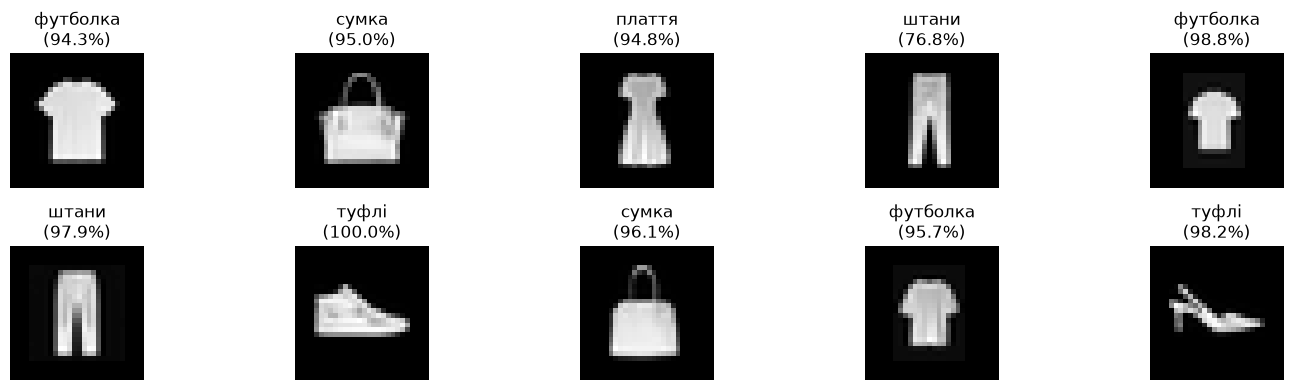

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tensorflow.keras.models import load_model

model_path = 'fashion_mnist_dense.keras'
print(f"Завантаження моделі з {model_path}...")
model = load_model(model_path)
print("Модель успішно завантажено!\n")

classes = ['футболка', 'штани', 'светр', 'плаття', 'пальто',
           'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')

    img_inverted = ImageOps.invert(img)

    bbox = img_inverted.getbbox()
    if bbox:
        img_inverted = img_inverted.crop(bbox)

    final_img = Image.new('L', (28, 28), color=0)

    img_inverted.thumbnail((20, 20), Image.Resampling.LANCZOS)

    offset_x = (28 - img_inverted.width) // 2
    offset_y = (28 - img_inverted.height) // 2
    final_img.paste(img_inverted, (offset_x, offset_y))

    img_array = np.array(final_img) / 255.0
    return img_array, img_array.reshape(1, 784)

images_folder = 'test_images'
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

if not image_files:
    print(f"Увага: Папка '{images_folder}' порожня. Додайте туди 10 зображень.")
else:
    print(f"Знайдено {len(image_files)} зображень для тестування.\n")

    plt.figure(figsize=(15, 2 * ((len(image_files) + 4) // 5)))

    for i, file_name in enumerate(image_files):
        img_path = os.path.join(images_folder, file_name)
        img_plot, img_for_model = preprocess_image(img_path)

        prediction = model.predict(img_for_model, verbose=0)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        print(f"Файл: {file_name}")
        print(f"-> Розпізнано як: {classes[predicted_class]} (Впевненість: {confidence:.2f}%)\n")

        plt.subplot(((len(image_files) + 4) // 5), 5, i + 1)
        plt.imshow(img_plot, cmap='gray')
        plt.title(f"{classes[predicted_class]}\n({confidence:.1f}%)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import tf2onnx
import onnx
import tensorflow as tf
import subprocess
import sys

model_keras = tf.keras.models.load_model('fashion_mnist_dense.keras')

export_dir = 'saved_model_dir'
model_keras.export(export_dir)

output_path = "fashion_mnist_dense.onnx"
subprocess.run([
    sys.executable, "-m", "tf2onnx.convert",
    "--saved-model", export_dir,
    "--output", output_path,
    "--opset", "13"
])

print(f"Готово! Модель успішно конвертовано та збережено як {output_path}")


INFO:tensorflow:Assets written to: saved_model_dir/assets


/Users/bohdan_best/Documents/університет/4 курс/Deep Learning/lab1/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop_10', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)
INFO:tensorflow:Assets written to: saved_model_dir/assets


Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_18')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  4790589328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4790591440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4402426704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4790591824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4790590480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4790592400: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-09-25 00:18:25,463 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-09-25 00:18:25,513 - INFO - Signatures found in model: [serve,serving_default].
2026-09-25 00:18:25,514 - WARNING - '--signature_def' not specified, using first signature: serve
2026-09-25 00:18:25,514 - INFO - Output names: ['output_0']
2026-09-25 00:18:25,648 - INFO - Using tensorflow=2.21.0, onnx=1.23.0, tf2onnx=1.17.0/None
2026-09-25 00:18:25,648 - INFO - Using opset <onnx, 13>
2026-09-25 00:18:25,653 - INFO - Computed 0 values for constant folding
2026-09-25 00:18:25,658 - INFO - Optimizing ONNX model
2026-09-25 00:18:25,711 - INFO - After optimization: Identity -2 (2->0)
2026-09-25 00:18:25,714 - INFO - 
2026-09-25 00:18:25,714 - INFO - Successfully converted TensorFlow model saved_model_dir to ONNX
2026-09-25 00:18:25,714 - INFO - Model inputs: ['input_layer_18']
2026-09-25 00:18:25,714 - INFO - Model outputs: ['output_0']
2026-09-25 00:18:25,714 - INFO - ONNX model is saved at fash

Готово! Модель успішно конвертовано та збережено як fashion_mnist_dense.onnx


=== Тестування моделі ONNX ===
Ім'я вхідного шару: input_layer_18

Тестове зображення розпізнано як: туфлі (Впевненість: 98.18%)
Результат збігається з моделлю Keras. ONNX-модель працює ідеально!


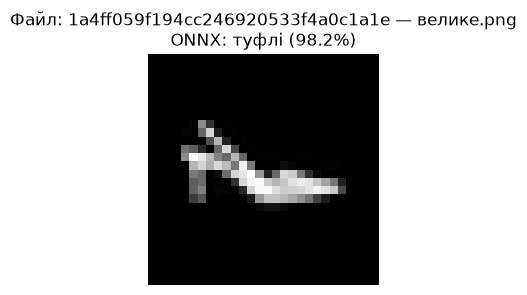

In [ ]:
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt

print("=== Тестування моделі ONNX ===")

session = ort.InferenceSession("fashion_mnist_dense.onnx")

input_name = session.get_inputs()[0].name
print(f"Ім'я вхідного шару: {input_name}")

if 'img_for_model' in locals():
    onnx_prediction = session.run(None, {input_name: img_for_model.astype(np.float32)})[0]
    
    predicted_class = np.argmax(onnx_prediction)
    confidence = np.max(onnx_prediction) * 100
    
    print(f"\nТестове зображення розпізнано як: {classes[predicted_class]} (Впевненість: {confidence:.2f}%)")
    print("Результат збігається з моделлю Keras. ONNX-модель працює ідеально!")
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img_plot, cmap='gray')
    plt.title(f"Файл: {file_name}\nONNX: {classes[predicted_class]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print("Будь ласка, спочатку виконайте попередню комірку з підготовкою зображень.")
